Ce document vise à traiter des données de simulations répétées pour voir ce qu'on peut en tirer.


In [4]:
import numpy as np 
import matplotlib.pyplot as plt


In [14]:
natoms = 64      
dumpfreq = 1000      
time = 14400000
dumpsteps = time // dumpfreq
numrep = 9
Nn = 8

I = np.linspace(0, 1, 1000)
w = np.zeros(Nn)

dp = [1e-5]
alphaq = [0.0083 ]
Seed = np.load('Seed.npy')
Seed = Seed.astype(int)

Poids_tot = np.zeros((len(dp),len(alphaq),numrep,natoms, dumpsteps+1, Nn))
Q_tot = np.zeros((len(dp),len(alphaq),numrep,natoms, dumpsteps+1))
Positions_tot = np.zeros((len(dp),len(alphaq),numrep,natoms, dumpsteps+1,2))

for p in range(len(dp)):
     for q in range(len(alphaq)):
        for nrep in range(numrep):
            Positions_tot[p,q,nrep,:,:,:] = np.load(f'Positions_{dp[p]}_{alphaq[q]}_{Seed[p,q,nrep]}.npy').swapaxes(0, 1)
            Poids_tot[p,q,nrep,:,:,:] = np.load(f'Weights_{dp[p]}_{alphaq[q]}_{Seed[p,q,nrep]}.npy').swapaxes(0, 1)
            #print(np.shape(Poids_tot[p,q,nrep,:,:,:]))
            Q_tot[p,q,nrep,:,:] = np.load(f'Rewards_{dp[p]}_{alphaq[q]}_{Seed[p,q,nrep]}.npy').swapaxes(0, 1)
            #print(np.shape(Q_tot[p,q,nrep,:,:]))


On trace l'évolution du controller moyen sur les différentes simulations.

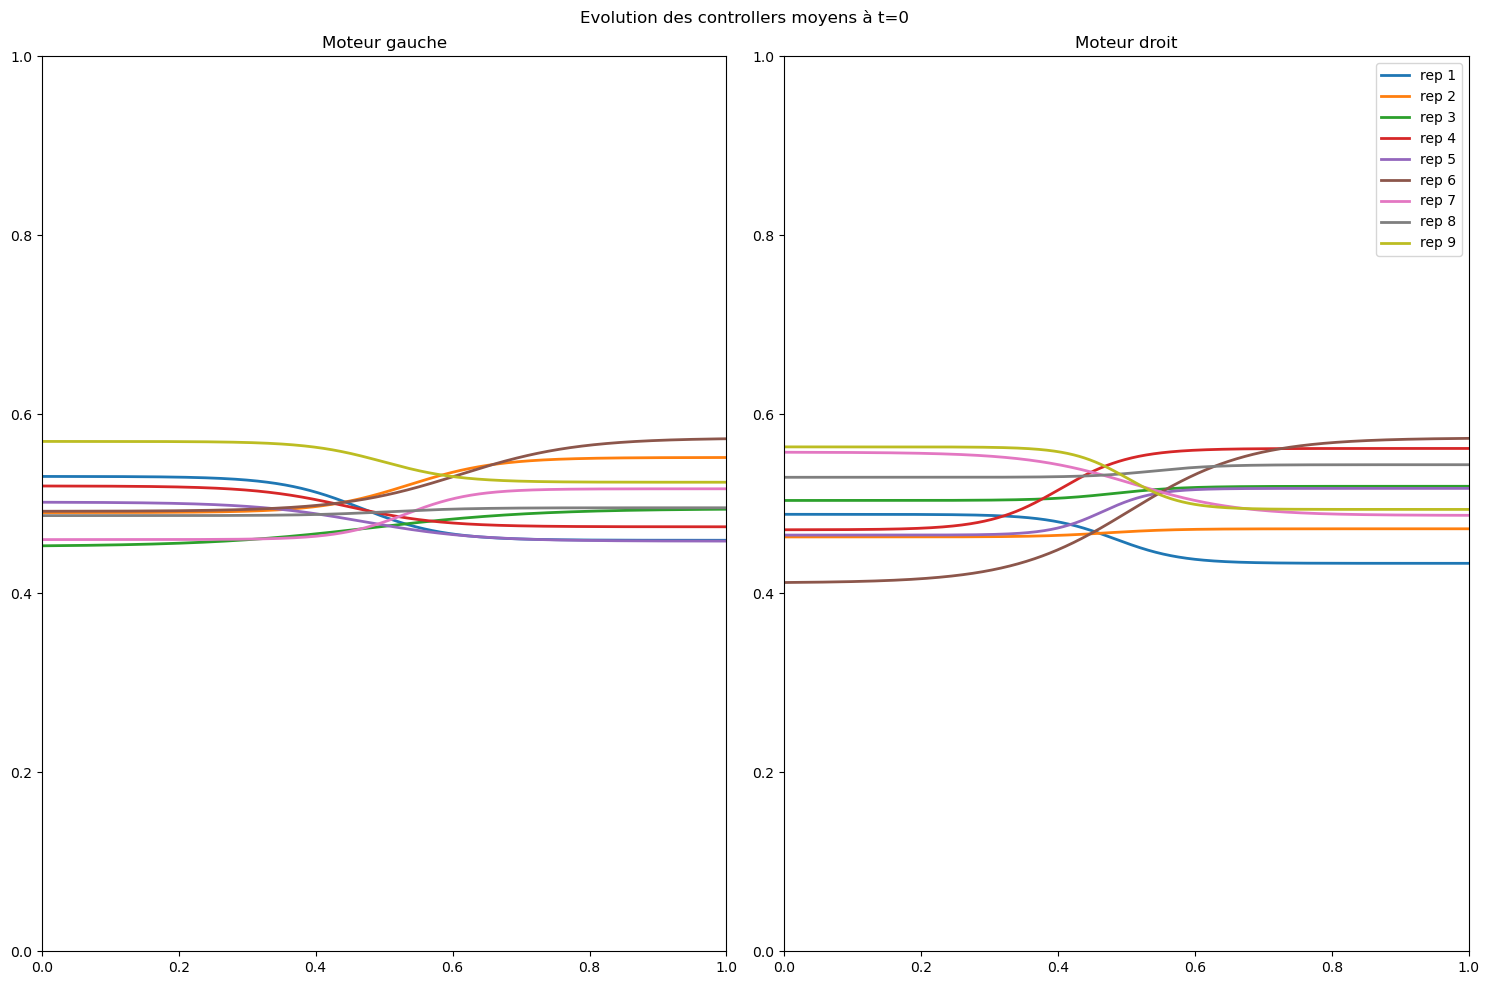

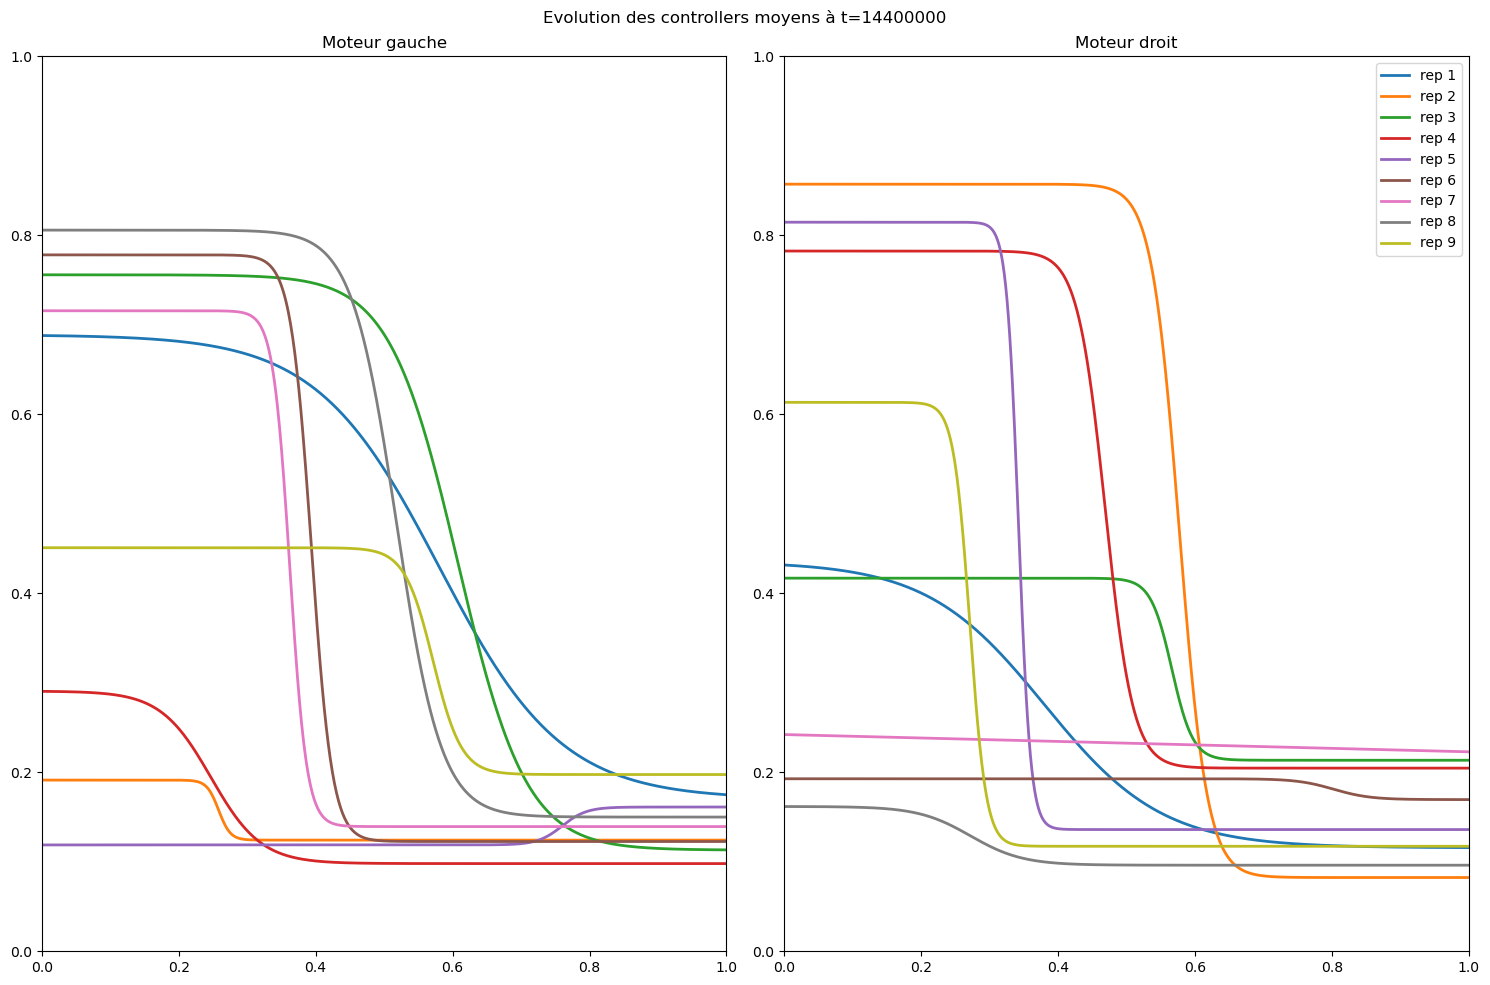

In [15]:
def slope(x):return (4*x)**4
def sigmoid(x):return 1 / (1 + np.exp(-x))

def controller(w):
    md = w[0] + (w[3] - w[0]) * sigmoid(slope(w[1]) * (I - w[2]))
    mg = w[4] + (w[7] - w[4]) * sigmoid(slope(w[5]) * (I - w[6]))
    return md, mg

time = np.linspace(0,dumpsteps, 2).astype(int)

for p in range(len(dp)):
    for q in range(len(alphaq)):
        for k in range(len(time)):
            fig, ax = plt.subplots(1,2, figsize = (15,10))
            for i in range(numrep):
                mean_p = np.mean(Poids_tot[p,q,i,:,time[k],:], axis = 0)
                md, mg = controller(mean_p)
                ax[0].plot(I, mg, lw=2, label=f'rep {i+1}')
                ax[1].plot(I, md, lw=2, label=f'rep {i+1}')
            ax[0].set_title('Moteur gauche')
            ax[0].set_xlim(0,1)
            ax[0].set_ylim(0,1)
            ax[1].set_title('Moteur droit')
            ax[1].set_xlim(0,1)
            ax[1].set_ylim(0,1)
            plt.legend()
            plt.suptitle(f'Evolution des controllers moyens à t={time[k]*dumpfreq}')
            plt.tight_layout()
            plt.show()

        

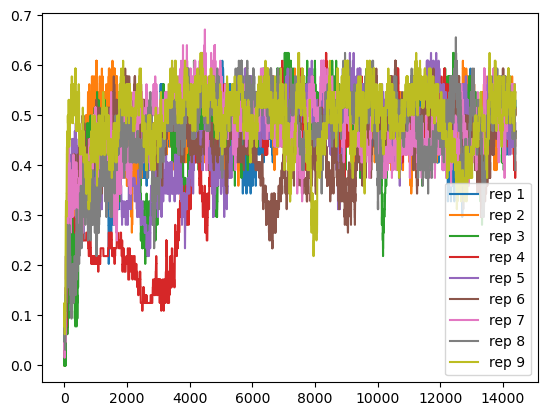

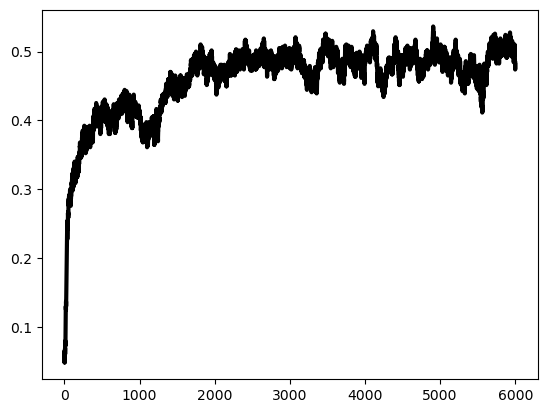

In [16]:
r2 = 14.44
mean_frac_lumi = np.zeros((len(dp), len(alphaq), dumpsteps+1))
for p in range(len(dp)):
    for q in range(len(alphaq)):
        plt.figure()
        for i in range(numrep):
            x = Positions_tot[p,q,i, :, :,0]
            y = Positions_tot[p,q,i, :, :,1]
            mask = (x**2 + y**2) <= r2
            frac_lumi = np.sum(mask, axis=0) / natoms
            mean_frac_lumi[p,q,:] += frac_lumi / numrep
            plt.plot(frac_lumi, label=f'rep {i+1}')
            plt.legend()
        plt.show()
        plt.figure()
        plt.plot(np.arange(dumpsteps+1)*dumpfreq*0.001/2.4 ,mean_frac_lumi[p,q,:], lw=3, color='black')




On trace l'évolution temporelle des poids et du score

In [12]:
def plot_stats_weights(Poids):
    mean_poids = np.mean(Poids, axis =0)
    std_poids = np. std(Poids, axis = 0)
    plt.figure()
    for i in range(Nn):
        plt.plot(np.arange(dumpsteps+1)*dumpfreq*0.001, mean_poids[:,i], label=f'Weight {i}')
    plt.xlabel('Time (s)')
    plt.ylabel('mean Weights')
    plt.legend()
    plt.show()
    for i in range(Nn):
        plt.plot(np.arange(dumpsteps+1)*dumpfreq*0.001, std_poids[:,i], label=f'Weight {i}')
    plt.xlabel('Time (s)')
    plt.ylabel('variance of Weights')
    plt.legend()
    plt.show()


def plot_stats_score(score):
    mean_score = np.mean(score, axis = 0)
    std_score = np. std(score, axis = 0)
    plt.figure()
    plt.plot(np.arange(dumpsteps+1)*dumpfreq*0.001, mean_score, label=f'score')
    plt.fill_between(np.arange(dumpsteps+1)*dumpfreq*0.001, mean_score-std_score, mean_score+std_score, alpha=0.3)
    plt.xlabel('Time (s)')
    plt.ylabel('score')
    plt.legend()
    plt.show()

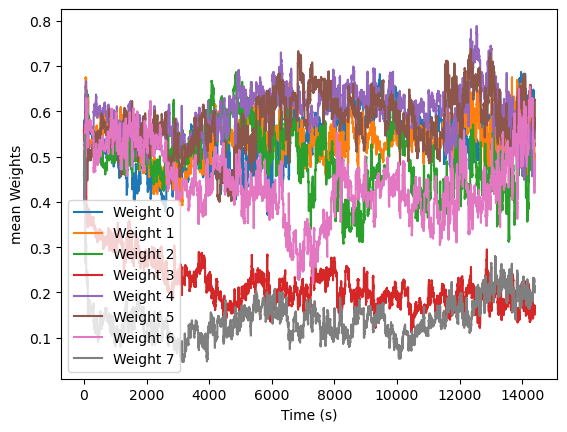

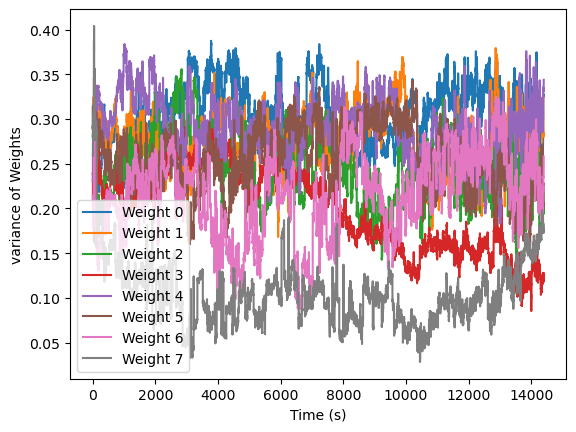

ValueError: x and y must have same first dimension, but have shapes (14401,) and (10, 64, 14401)

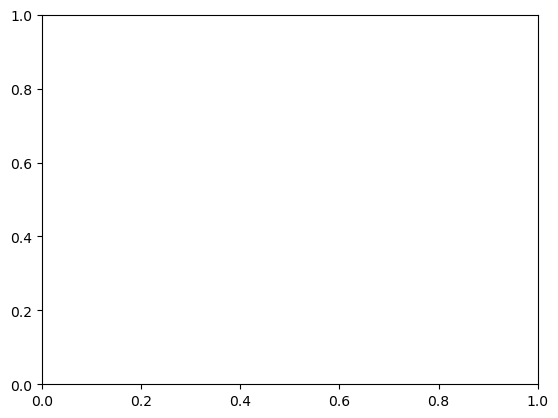

In [13]:
i = 0
for p in range(len(dp)):
    for q in range(len(alphaq)):
        for k in range(numrep):
            plot_stats_weights(np.mean(Poids_tot[k,:,:,i], axis=0))
            plot_stats_score(Q_tot[k,:,:])

histogrammes finaux 

In [10]:
nbins = 50
def plot_hist_final_weights(Poids, dp, alphaq):
    final_weights = Poids[:,-1,:]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    for i in range(Nn//2): 
        ax = axes[i//2, i%2]
        ax.hist(final_weights[:, i], bins=nbins,density = True, alpha=0.6, label=f'W{i}')
        ax.hist(final_weights[:, i + Nn//2], bins=nbins, density = True, alpha=0.6, label=f'W{i + Nn//2}')
        ax.set_title(f'Weights {i} & {i + Nn//2}')
        ax.legend()
        ax.set_title(f'{dp},{alphaq}')
    plt.tight_layout()
    plt.show()

Chargement des données

1.0


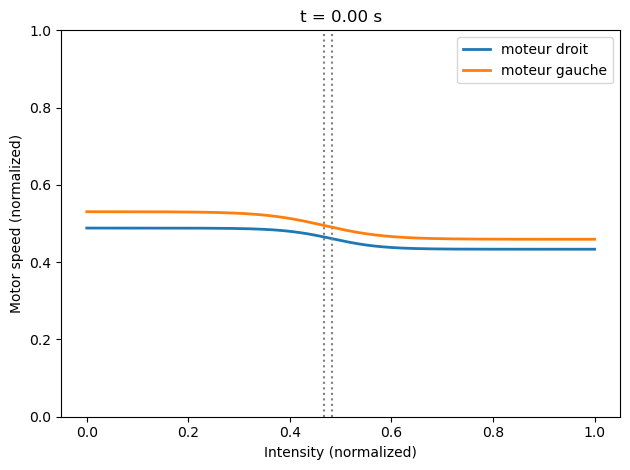

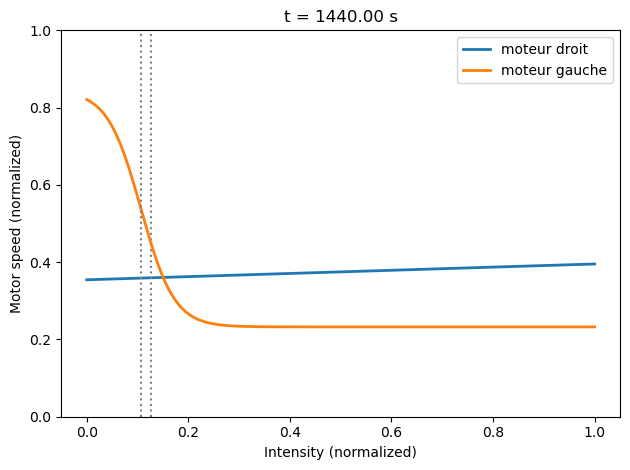

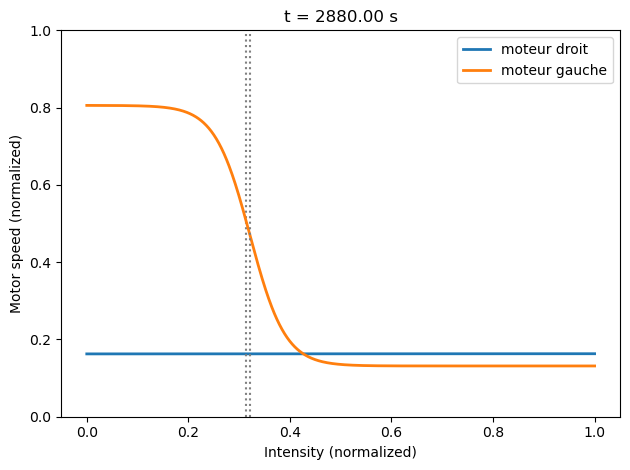

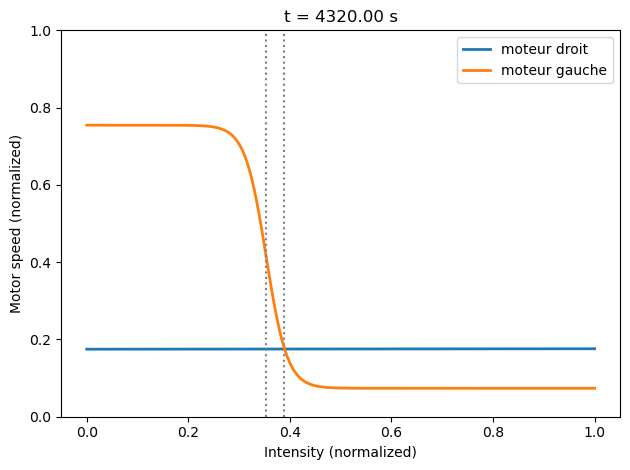

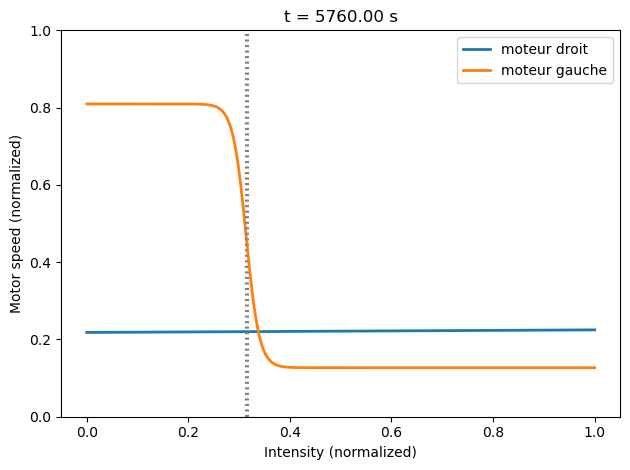

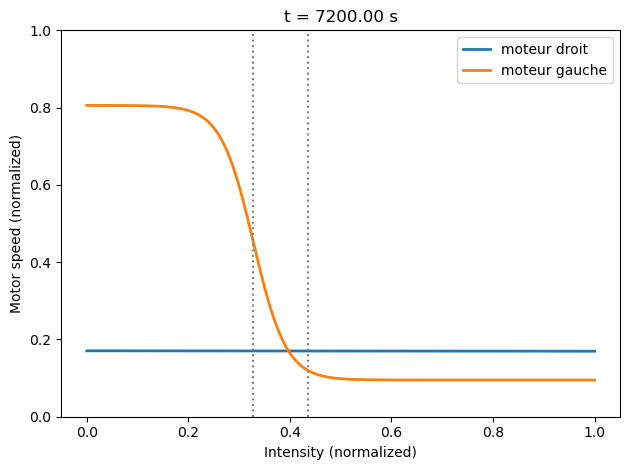

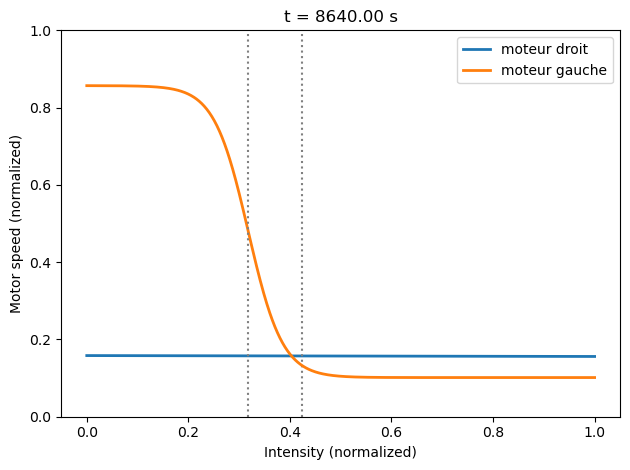

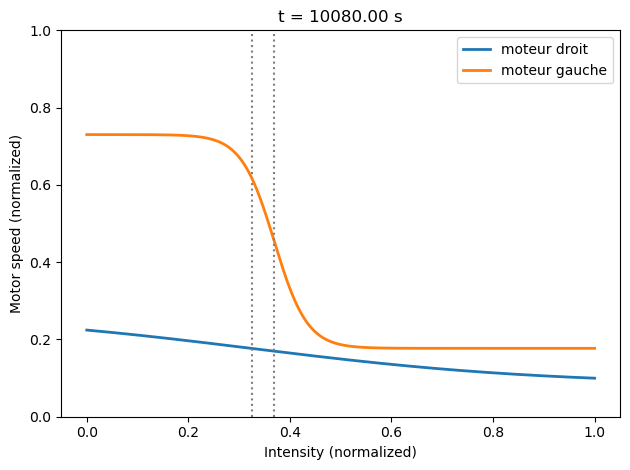

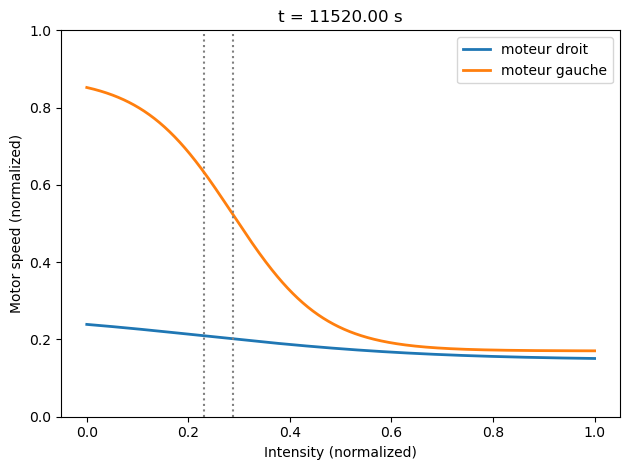

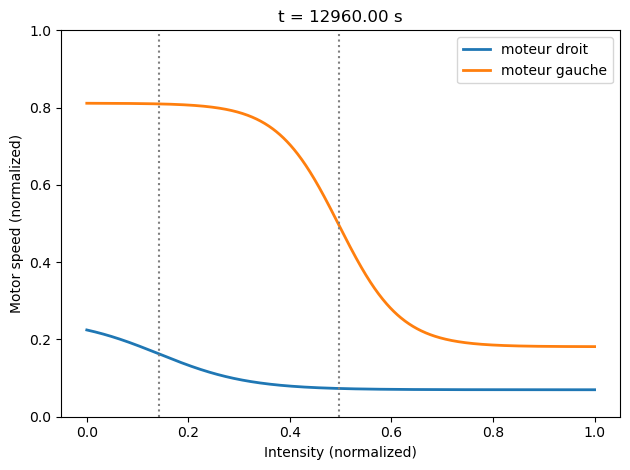

In [11]:
Poids_tot = np.zeros((numrep,natoms, dumpsteps+1, Nn))
Q_tot = np.zeros((numrep,natoms, dumpsteps+1))

for p in range(len(dp)):
    for q in range(len(alphaq)):
            for nrep in range(numrep):
                if Seed[p,q,nrep] not in [0, 29291]:
                    Poids = np.load(f'Weights_{dp[p]}_{alphaq[q]}_{Seed[p,q,nrep]}.npy')
                    #print(Poids.shape)
                    Poids = Poids.swapaxes(0, 1)
                    print(np.max(Poids))
                    Q = np.load(f'Rewards_{dp[p]}_{alphaq[q]}_{Seed[p,q,nrep]}.npy')
                    Q = Q.swapaxes(0, 1)
                    Poids_tot[nrep,:,:,:] = Poids
                    Q_tot[nrep,:,:] = Q
                Poids_tot_flat = np.concatenate(Poids_tot,axis =0)
                Q_tot_flat = np.concatenate(Q_tot,axis = 0)
            """plot_stats_weights(Poids_tot_flat)
            plot_stats_score(Q_tot_flat)
            plot_hist_final_weights(Poids_tot_flat, dp[p], alphaq[q])"""
            plot_controller(np.mean(Poids_tot_flat,axis =0), Nn)

In [20]:
"""for p in range(len(dp)):
    for q in range(len(alphaq)):
            for nrep in range(numrep):
                Poids = np.load(f'Weights_{dp[p]}_{alphaq[q]}_{Seed[p,q,nrep]}.npy')
                Poids = Poids.swapaxes(0, 1)
                print(np.max(Poids))
                Q = np.load(f'Rewards_{dp[p]}_{alphaq[q]}_{Seed[p,q,nrep]}.npy')
                Q = Q.swapaxes(0, 1)
                Poids_tot[nrep,:,:,:] = Poids
                Q_tot[nrep,:,:] = Q
            Poids_tot_flat = np.concatenate(Poids_tot,axis =0)
            Q_tot_flat = np.concatenate(Q_tot,axis = 0)"""

"for p in range(len(dp)):\n    for q in range(len(alphaq)):\n            for nrep in range(numrep):\n                Poids = np.load(f'Weights_{dp[p]}_{alphaq[q]}_{Seed[p,q,nrep]}.npy')\n                Poids = Poids.swapaxes(0, 1)\n                print(np.max(Poids))\n                Q = np.load(f'Rewards_{dp[p]}_{alphaq[q]}_{Seed[p,q,nrep]}.npy')\n                Q = Q.swapaxes(0, 1)\n                Poids_tot[nrep,:,:,:] = Poids\n                Q_tot[nrep,:,:] = Q\n            Poids_tot_flat = np.concatenate(Poids_tot,axis =0)\n            Q_tot_flat = np.concatenate(Q_tot,axis = 0)"

In [ ]:
"""def plot_controller(X, NN):
    plt.ion()  # mode interactif (obligatoire pour l’animation simple)
    fig, ax = plt.subplots()

    for t in range(0, dumpsteps, dumpsteps // 10):  # ~400 frames max
        for k in range(Nn):
            w[k] = X[t,k]
    
        # calcul des profils moteurs
        md = w[0] + (w[3] - w[0]) * sigmoid(slope(w[1]) * (I - w[2]))
        mg = w[4] + (w[7] - w[4]) * sigmoid(slope(w[5]) * (I - w[6]))
        
        # efface la figure précédente
        plt.clf()
        plt.plot(I, md, lw=2, label='moteur droit')
        plt.axvline(w[2], ls=':', color='gray') # seuil du moteur droit 
        plt.plot(I, mg, lw=2, label='moteur gauche')
        plt.axvline(w[6], ls=':', color='gray') # seuil du moteur gauche
        plt.xlabel('Intensity (normalized)')
        plt.ylabel('Motor speed (normalized)')
        plt.title(f"t = {t * dumpfreq * 0.001:.2f} s")
        plt.ylim(0, 1)
        plt.legend()
        plt.tight_layout()

        plt.pause(0.1)  # temps d’attente entre deux frames

    plt.ioff()
    plt.show()"""